In [1]:
from google.colab import files
uploaded = files.upload()  # select your v3_weighted_efficientnet.keras file
print("Uploaded:", list(uploaded.keys()))

Saving v3_weighted_efficientnet.keras to v3_weighted_efficientnet.keras
Uploaded: ['v3_weighted_efficientnet.keras']


In [2]:
import tensorflow as tf

model_filename = list(uploaded.keys())[0]
model = tf.keras.models.load_model(model_filename)

base_model = next(l for l in model.layers if l.__class__.__name__ == "Functional")
gap_layer = next(l for l in model.layers if l.__class__.__name__ == "GlobalAveragePooling2D")
dense_layer = next(l for l in model.layers if l.__class__.__name__ == "Dense")

print("Retrieved:", base_model.name, gap_layer.name, dense_layer.name)
model.summary()

Retrieved: efficientnetb0 global_average_pooling2d dense


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,778,394 (25.86 MB)

 Trainable params: 1,359,927 (5.19 MB)

 Non-trainable params: 2,698,611 (10.29 MB)

 Optimizer params: 2,719,856 (10.38 MB)

In [3]:
def find_last_conv_layer_name(base_model):
    layer_names = [l.name for l in base_model.layers]
    if "relu" in layer_names:
        return "relu"
    for layer in reversed(base_model.layers):
        try:
            shape = layer.output.shape
        except Exception:
            continue
        if len(shape) == 4:
            return layer.name
    return None

last_conv_layer_name = find_last_conv_layer_name(base_model)
print("Detected last conv layer:", last_conv_layer_name)

def make_gradcam_heatmap(img_array, base_model, gap_layer, dense_layer, class_index, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output],
    )

    with tf.GradientTape() as tape:
        conv_output, base_features = grad_model(img_array)
        pooled = gap_layer(base_features)
        predictions = dense_layer(pooled)
        class_output = predictions[:, class_index]

    grads = tape.gradient(class_output, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

Detected last conv layer: top_activation


In [4]:
import numpy as np
from PIL import Image
import io, base64

def overlay_heatmap(original_image_array, heatmap, alpha=0.4):
    h, w = original_image_array.shape[:2]
    heatmap_img = Image.fromarray(np.uint8(heatmap * 255)).resize((w, h), resample=Image.BILINEAR)
    heatmap_resized = np.array(heatmap_img) / 255.0

    heatmap_colored = np.zeros((h, w, 3), dtype=np.float32)
    heatmap_colored[..., 0] = heatmap_resized

    original_uint8 = (original_image_array * 255).astype(np.float32)
    overlay = original_uint8 * (1 - alpha) + heatmap_colored * 255 * alpha
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)

    buf = io.BytesIO()
    Image.fromarray(overlay).save(buf, format="PNG")
    return base64.b64encode(buf.getvalue()).decode("utf-8")

In [5]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [6]:

path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

import os
csv_candidates = [os.path.join(root, f) for root, _, files in os.walk(path) for f in files if f.endswith(".csv")]
img_dir_candidates = [root for root, dirs, files in os.walk(path) if any(f.lower().endswith(".jpg") for f in files)]

import pandas as pd
metadata_path = next(p for p in csv_candidates if "metadata" in p.lower())
meta_df = pd.read_csv(metadata_path)

def find_image_path(image_id):
    for img_dir in img_dir_candidates:
        candidate = os.path.join(img_dir, f"{image_id}.jpg")
        if os.path.exists(candidate):
            return candidate
    return None

meta_df["image_path"] = meta_df["image_id"].apply(find_image_path)
meta_df = meta_df.dropna(subset=["image_path"]).reset_index(drop=True)

Using Colab cache for faster access to the 'skin-cancer-mnist-ham10000' dataset.


In [7]:
DX_TO_FULLNAME = {
    "akiec": "Actinic keratoses and intraepithelial carcinoma", "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions", "df": "Dermatofibroma", "mel": "Melanoma",
    "nv": "Melanocytic nevi", "vasc": "Vascular lesions",
}
DX_CODES = sorted(DX_TO_FULLNAME.keys())
CONDITIONS = [DX_TO_FULLNAME[c] for c in DX_CODES]

melanoma_samples = meta_df[meta_df["dx"] == "mel"].sample(3, random_state=42)
other_samples = meta_df[meta_df["dx"] != "mel"].sample(2, random_state=42)
test_samples = pd.concat([melanoma_samples, other_samples]).reset_index(drop=True)

print("Test images selected (3 real melanoma cases + 2 others):")
print(test_samples[["image_id", "dx"]])

Test images selected (3 real melanoma cases + 2 others):
       image_id   dx
0  ISIC_0028847  mel
1  ISIC_0027102  mel
2  ISIC_0028508  mel
3  ISIC_0033153   nv
4  ISIC_0031535   nv


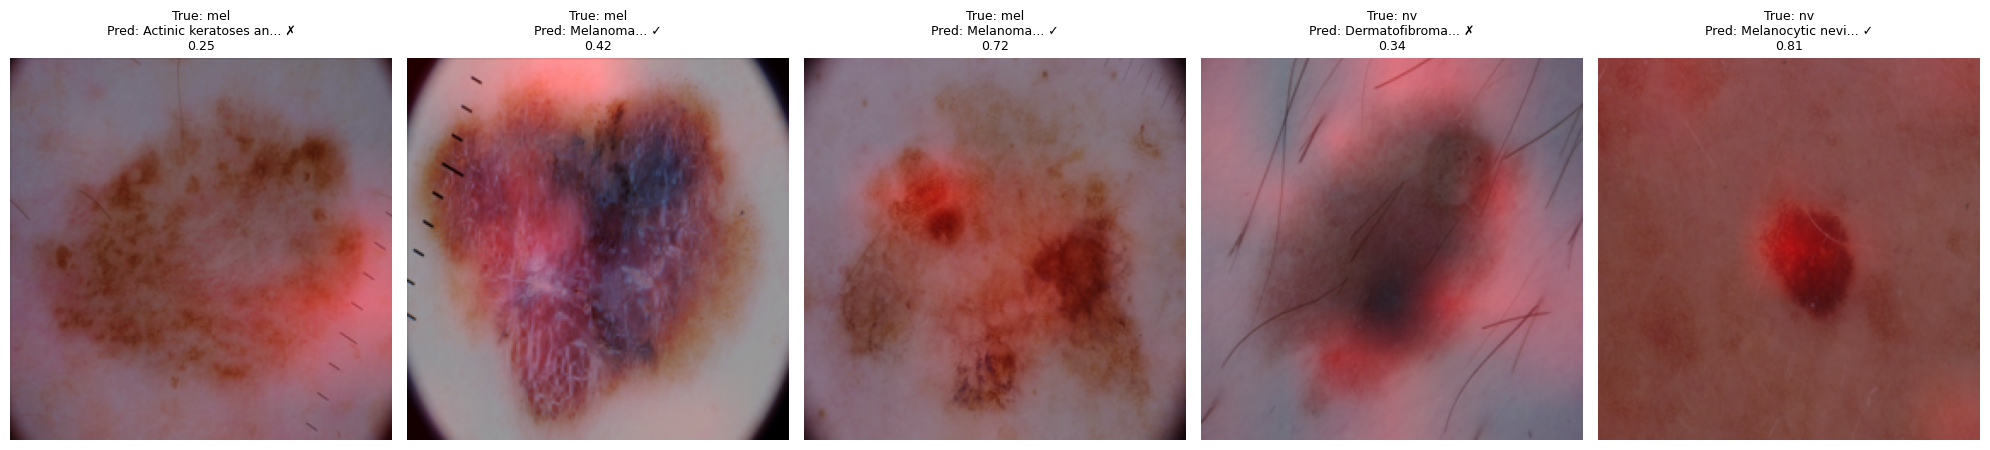

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(test_samples), figsize=(4 * len(test_samples), 4.5))

for ax, (_, row) in zip(axes, test_samples.iterrows()):
    img = Image.open(row["image_path"]).convert("RGB").resize((224, 224))
    img_array = np.asarray(img, dtype=np.float32)  # RAW [0,255] scale -- matches training
    batch = np.expand_dims(img_array, axis=0)

    predictions = model.predict(batch, verbose=0)[0]
    top_class_index = int(np.argmax(predictions))
    top_prob = predictions[top_class_index]
    true_label = DX_TO_FULLNAME[row["dx"]]

    heatmap = make_gradcam_heatmap(batch, base_model, gap_layer, dense_layer, top_class_index, last_conv_layer_name)
    overlay_b64 = overlay_heatmap(img_array / 255.0, heatmap)
    overlay_img = Image.open(io.BytesIO(base64.b64decode(overlay_b64)))

    correct = "✓" if CONDITIONS[top_class_index] == true_label else "✗"
    ax.imshow(overlay_img)
    ax.set_title(f"True: {row['dx']}\nPred: {CONDITIONS[top_class_index][:20]}... {correct}\n{top_prob:.2f}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()